In [1]:
%pip install numpy tensorflow scikit-learn matplotlib seaborn

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl (350.9 MB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# CELLULE 1: IMPORTATION DES BIBLIOTHÈQUES NÉCESSAIRES
# ================================================

# Imports de base pour manipuler les données et les fichiers
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports TensorFlow/Keras pour le deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Augmentation des données
from tensorflow.keras.applications import VGG16  # Modèle pré-entraîné VGG16
from tensorflow.keras.models import Model, load_model  # Pour créer et charger les modèles
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout  # Couches personnalisées
from tensorflow.keras.optimizers import Adam  # Optimiseur Adam
from tensorflow.keras.regularizers import l2  # Régularisation L2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau  # Callbacks d'entraînement

# Imports scikit-learn pour les métriques
from sklearn.metrics import classification_report, confusion_matrix  # Évaluation du modèle


In [2]:
# CELLULE 2: DÉFINITION DES HYPERPARAMÈTRES
# ============================================

# Taille des images d'entrée (VGG16 accepte 224x224)
IMG_SIZE = (224, 224)

# Nombre d'images traitées par batch
BATCH_SIZE = 32

# Nombre d'époques d'entraînement
EPOCHS = 50

# Chemins des répertoires de données
TRAIN_DIR = "../data/train"  # Données d'entraînement
VAL_DIR   = "../data/val"    # Données de validation
TEST_DIR  = "../data/test"   # Données de test


In [3]:
# CELLULE 3: CONFIGURATION DES DATA GENERATORS (AUGMENTATION DES DONNÉES)
# ==========================================================================

# DataGenerator pour l'ensemble d'entraînement avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisation des pixels (0-1)
    rotation_range=25,  # Rotation aléatoire jusqu'à 25 degrés
    width_shift_range=0.2,  # Décalage horizontal aléatoire
    height_shift_range=0.2,  # Décalage vertical aléatoire
    shear_range=0.15,  # Cisaillement aléatoire
    zoom_range=0.15,  # Zoom aléatoire
    brightness_range=[0.8, 1.2],  # Variation de luminosité
    horizontal_flip=True,  # Flip horizontal aléatoire
    fill_mode='nearest'  # Mode de remplissage pour pixels manquants
)

# DataGenerator pour validation (sans augmentation, seulement normalisation)
val_datagen = ImageDataGenerator(rescale=1./255)

# DataGenerator pour test (sans augmentation, seulement normalisation)
test_datagen = ImageDataGenerator(rescale=1./255)


In [4]:
# CELLULE 4: CHARGEMENT DES DONNÉES DEPUIS LES RÉPERTOIRES
# ===========================================================

# Chargement des données d'entraînement
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,  # Redimensionner à 224x224
    batch_size=BATCH_SIZE,  # Batch de 32 images
    class_mode="sparse"  # Labels en format entier (0, 1, 2, 3)
)

# Chargement des données de validation
val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse"
)

# Chargement des données de test
test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False  # Pas de mélange pour la cohérence des prédictions
)

# Affichage des indices des classes
print(train_data.class_indices)


Found 6326 images belonging to 4 classes.
Found 1035 images belonging to 4 classes.
Found 771 images belonging to 4 classes.
{'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TUBERCULOSIS': 3}


In [5]:
# CELLULE 5: CHARGEMENT DU MODÈLE VGG16 PRÉ-ENTRAÎNÉ
# ===================================================

# Charger VGG16 avec poids ImageNet (sans couches supérieures)
base_model = VGG16(
    weights="imagenet",  # Poids pré-entraînés sur ImageNet
    include_top=False,  # Exclure les couches de classification (on veut juste les features)
    input_shape=(224, 224, 3)  # Entrée RGB 224x224
)

# Geler les poids du modèle de base (transfer learning)
base_model.trainable = False

# S'assurer que tous les layers sont gelés
for layer in base_model.layers:
    layer.trainable = False


In [6]:
# CELLULE 6: CONSTRUCTION DE LA TÊTE DU MODÈLE (HEAD LAYERS)
# ============================================================

# Récupérer la sortie du modèle de base
x = base_model.output

# Appliquer Global Average Pooling pour réduire la dimensionnalité
x = GlobalAveragePooling2D()(x)

# Couche Dense avec activation ReLU et régularisation L2 pour éviter l'overfitting
x = Dense(512, activation="relu", kernel_regularizer=l2(0.01))(x)

# Dropout pour prévenir l'overfitting (50% des neurones désactivés)
x = Dropout(0.5)(x)

# Deuxième couche Dense avec 128 neurones et régularisation L2
x = Dense(128, activation="relu", kernel_regularizer=l2(0.01))(x)

# Deuxième Dropout
x = Dropout(0.5)(x)

# Couche de sortie avec softmax (4 classes: COVID19, NORMAL, PNEUMONIA, TUBERCULOSIS)
output = Dense(4, activation="softmax")(x)

# Créer le modèle complet
model = Model(inputs=base_model.input, outputs=output)


In [7]:
# CELLULE 7: AFFICHER UN RÉSUMÉ DE L'ARCHITECTURE DU MODÈLE
# ===========================================================

# Afficher les couches et le nombre de paramètres
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,043,524 (57.39 MB)

 Trainable params: 328,836 (1.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# CELLULE 8: COMPILATION DU MODÈLE
# ==================================

# Compiler le modèle avec l'optimiseur, la fonction de perte et les métriques
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Optimiseur Adam avec learning rate bas
    loss="sparse_categorical_crossentropy",  # Perte pour classification multi-classe
    metrics=["accuracy"]  # Métrique: précision
)


In [9]:
# CELLULE 9: CONFIGURATION DES CALLBACKS POUR L'ENTRAÎNEMENT
# ===========================================================

# EarlyStopping: arrêter l'entraînement si val_loss ne s'améliore pas
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitorer la perte de validation
    patience=10,  # Attendre 10 epochs sans amélioration avant d'arrêter
    restore_best_weights=True,  # Restaurer les poids du meilleur modèle
    mode='min',  # Chercher à minimiser val_loss
    verbose=1  # Afficher les informations
)

# ReduceLROnPlateau: réduire le learning rate si val_loss stagne
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Multiplier le learning rate par 0.5
    patience=5,  # Attendre 5 epochs avant de réduire
    min_lr=1e-7,  # Learning rate minimum
    verbose=1
)

# ModelCheckpoint: sauvegarder le meilleur modèle basé sur val_accuracy
checkpoint = ModelCheckpoint(
    "models/best_vgg16_model.h5",  # Chemin de sauvegarde
    monitor="val_accuracy",  # Monitorer la précision de validation
    save_best_only=True,  # Sauvegarder seulement le meilleur
    mode='max',  # Chercher à maximiser val_accuracy
    verbose=1
)


In [10]:
# CELLULE 10: CHARGER LE MEILLEUR MODÈLE SAUVEGARDÉ
# ===================================================

# Charger le modèle pré-entraîné avec les meilleurs poids
model = load_model("models/best_vgg16_model.h5")

# Recompiler le modèle après le chargement
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# CELLULE 11: ENTRAÎNEMENT DU MODÈLE
# ===================================

# Entraîner le modèle sur les données d'entraînement
history = model.fit(
    train_data,  # Données d'entraînement
    validation_data=val_data,  # Données de validation
    epochs=5,  # Nombre d'epochs
    callbacks=[checkpoint, early_stopping, reduce_lr],  # Callbacks configurés
    verbose=1  # Afficher la progression
)

Epoch 1/5
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8638 - loss: 0.5406

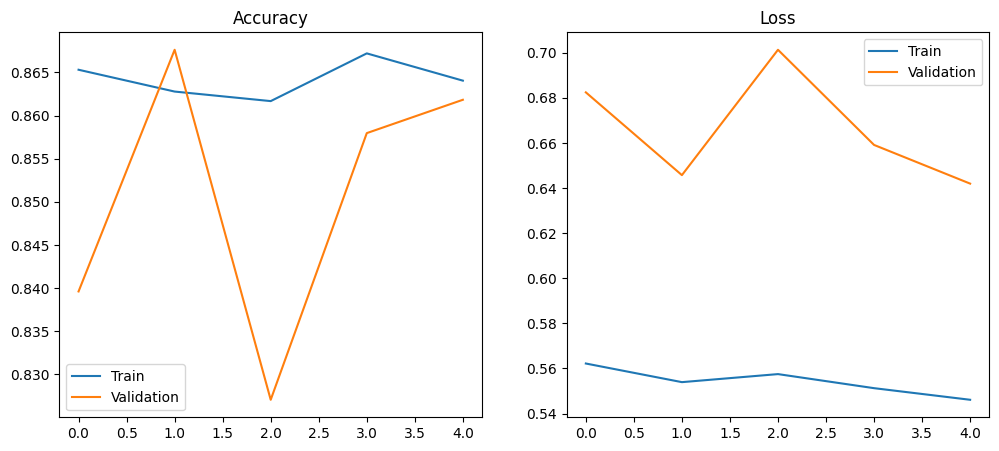

In [ ]:
# CELLULE 12: VISUALISER LES COURBES D'APPRENTISSAGE
# ===================================================

# Créer une figure avec 2 sous-graphiques
plt.figure(figsize=(12, 5))

# Sous-graphique 1: Courbe de précision (accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")  # Précision d'entraînement
plt.plot(history.history["val_accuracy"], label="Validation")  # Précision de validation
plt.title("Accuracy")
plt.legend()

# Sous-graphique 2: Courbe de perte (loss)
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")  # Perte d'entraînement
plt.plot(history.history["val_loss"], label="Validation")  # Perte de validation
plt.title("Loss")
plt.legend()

plt.show()


In [ ]:
# CELLULE 13: ÉVALUER LE MODÈLE SUR L'ENSEMBLE DE TEST
# ======================================================

# Évaluer le modèle et obtenir la perte et la précision
test_loss, test_acc = model.evaluate(test_data)

# Afficher la précision du test
print(f"Test Accuracy : {test_acc:.4f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.8612 - loss: 0.5814
25/25 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.8612 - loss: 0.5814
Test Accuracy : 0.8612
Test Accuracy : 0.8612


In [ ]:
# CELLULE 14: RÉCUPÉRER LES NOMS DES CLASSES
# ============================================

# Extraire les noms des classes à partir du dictionnaire des indices
class_names = list(test_data.class_indices.keys())


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


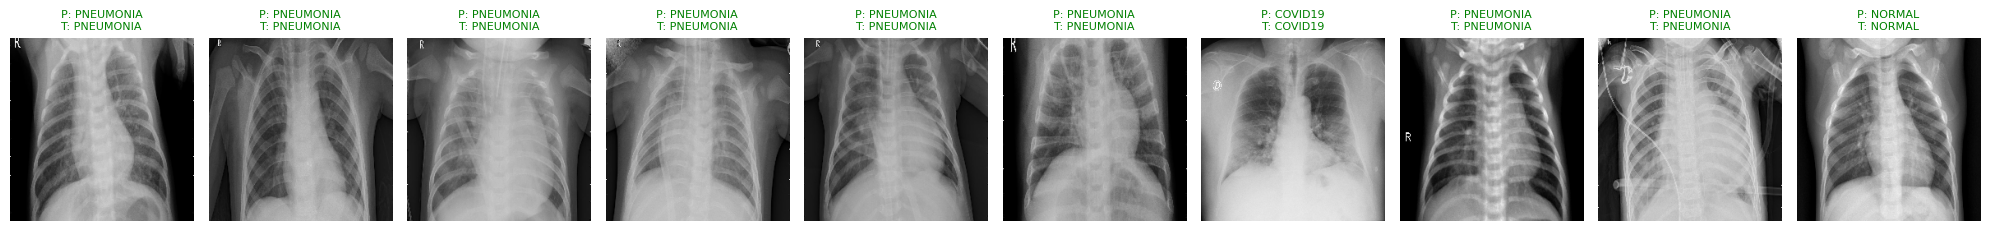

In [ ]:
# CELLULE 15: VISUALISER 10 PRÉDICTIONS ALÉATOIRES
# ==================================================

# 1️ Récupérer toutes les images et labels du test set
all_images = []
all_labels = []

for batch_images, batch_labels in test_data:
    all_images.append(batch_images)
    all_labels.extend(batch_labels)  # utiliser extend et non append pour aplatir correctement

    # Stop si on a parcouru toutes les images
    if len(all_labels) >= test_data.n:
        break

# Concaténer tous les batches en un seul array
all_images = np.vstack(all_images)
# Convertir les labels en array d'entiers
all_labels = np.array(all_labels, dtype=int)

# 2️ Tirer 10 images aléatoires de l'ensemble de test
indices = np.random.choice(len(all_images), size=10, replace=False)

# 3️ Affichage avec prédiction et couleur correct/faux
plt.figure(figsize=(20, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 10, i + 1)
    
    # Récupérer et afficher l'image
    img = all_images[idx]
    if img.shape[-1] == 3:  # Image RGB
        plt.imshow((img * 255).astype("uint8"))
    else:  # Image en niveaux de gris
        plt.imshow(img.squeeze(), cmap='gray')
    plt.axis("off")
    
    # Faire la prédiction
    pred_class = np.argmax(model.predict(img[np.newaxis, ...]))
    true_class = int(all_labels[idx])
    
    # Déterminer la couleur (vert si correct, rouge sinon)
    color = 'green' if pred_class == true_class else 'red'
    
    # Afficher le titre avec prédiction (P:) et vraie classe (T:)
    plt.title(f"P: {class_names[pred_class]}\nT: {class_names[true_class]}", color=color, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# CELLULE 16: AFFICHER LES STATISTIQUES DES DONNÉES DE TEST
# ===========================================================

# Afficher le mapping classe-index
print(test_data.class_indices)

# Afficher le nombre total d'images de test
print(len(test_data.filepaths))

# Compter le nombre d'images par classe
unique, counts = np.unique(true_classes, return_counts=True)
print(dict(zip(unique, counts)))


{'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TUBERCULOSIS': 3}
771
{np.float32(1.0): np.int64(32)}


25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step


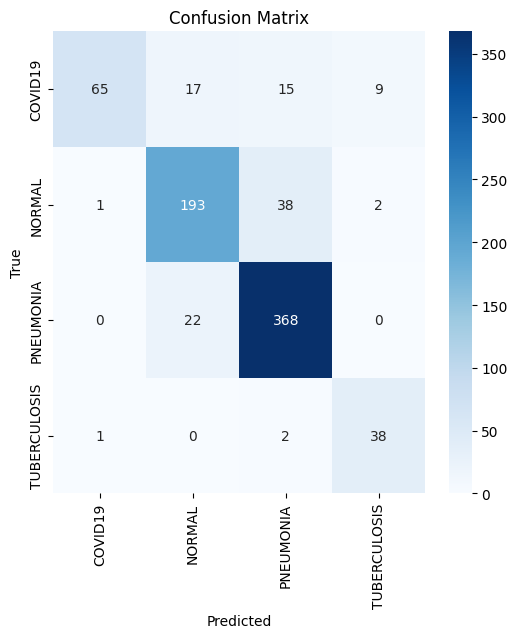

In [ ]:
# CELLULE 17: GÉNÉRER ET VISUALISER LA MATRICE DE CONFUSION
# ============================================================

# 1️ Faire des prédictions sur tout l'ensemble de test
all_preds = model.predict(test_data, verbose=1)  # retourne les probabilités
# Convertir les probabilités en classes prédites
all_pred_classes = np.argmax(all_preds, axis=1)

# 2️ Calculer la matrice de confusion
cm = confusion_matrix(test_data.classes, all_pred_classes)

# 3️ Afficher la matrice de confusion en heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
